The eddington limit for accretion ("gravity balances out with photons coming from the accretion") for some eddinton luminosity $L_{\rm Edd} = \epsilon \dot{m}_{\rm Edd} c^2$

$$\dot{m}_{\mathrm{Edd}}={\frac{4\pi G M_{\rm BH}\mathrm{m_{p}}}{\eta\sigma_{\mathrm{T}}\mathrm{c}}}$$



In [125]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
from matplotlib.colors import LogNorm

warnings.filterwarnings("ignore", category=RuntimeWarning)


def eddington_accretion_rate(M_BH, lambda_Edd, eta=0.1):
    """
    Calculate the mass accretion rate (in solar masses per year) for a given Eddington ratio.

    Parameters:
        M_BH (float): Mass of the black hole in solar masses.
        lambda_Edd (float): Eddington ratio.
        eta (float): Radiative efficiency (default is 0.1).

    Returns:
        float: Mass accretion rate in solar masses per year.
    """
    # Constants
    c = 3e10  # Speed of light in cm/s
    grams_per_solar_mass = 1.989e33  # Solar mass in grams
    seconds_per_year = 3.154e7  # Seconds in a year
    L_Edd_factor = 1.26e38  # Eddington luminosity factor in erg/s per solar mass

    # Compute Eddington accretion rate in grams per second
    M_dot_Edd_g_per_s = (L_Edd_factor * M_BH) / (eta * c**2)

    # Adjust by Eddington ratio
    M_dot_g_per_s = lambda_Edd * M_dot_Edd_g_per_s

    # Convert to solar masses per year
    M_dot_solar_per_year = M_dot_g_per_s / grams_per_solar_mass * seconds_per_year

    return M_dot_solar_per_year


# Example usage
M_BH = np.geomspace(1e4, 1e8, 200)  # Black hole mass in solar masses
f_Edd = 1  # Eddington ratio
accretion_rate = eddington_accretion_rate(M_BH, f_Edd)
# print(accretion_rate)

In [63]:
from yt.utilities.cosmology import Cosmology


def z_from_t_myr(t_myr):
    """
    The times are in reasonable agreement, within 1 Myr, deviations due
    to the used value of parameters, which change somewhat over cosmic
    time
    """
    co = Cosmology(
        hubble_constant=0.70,
        omega_matter=0.270000010728836,
        omega_radiation=0.0,
        omega_lambda=0.730000019073486,
    )
    z = np.array(co.z_from_t(t_myr * 1e6 * 3.154 * 1e7))

    return z


def t_myr_from_z(z):
    co = Cosmology(
        hubble_constant=0.70,
        omega_matter=0.270000010728836,
        omega_radiation=0.0,
        omega_lambda=0.730000019073486,
    )
    t_myr = np.array(co.t_from_z(z) / 1e6 / 3.154 / 1e7)

    return t_myr

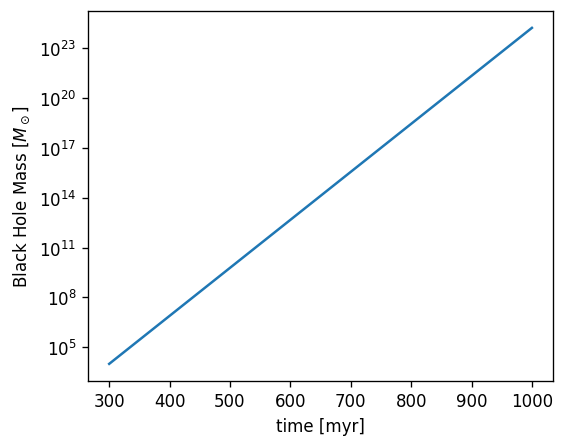

In [67]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from astropy.cosmology import Planck18 as cosmo  # Planck 2018 cosmology


# Define constants and functions (same as before)
def eddington_accretion_rate(M_BH, eta):
    G = 6.674e-8
    m_p = 1.673e-24
    sigma_T = 6.652e-25
    c = 3e10
    grams_per_solar_mass = 1.989e33
    seconds_per_year = 3.154e7
    M_BH_g = M_BH * grams_per_solar_mass
    M_dot_Edd_g_per_s = (4 * np.pi * G * M_BH_g * m_p) / (eta * sigma_T * c)
    M_dot_Edd_solar_per_year = (
        M_dot_Edd_g_per_s / grams_per_solar_mass * seconds_per_year
    )
    return M_dot_Edd_solar_per_year


def black_hole_mass_ode(bh_mass, t, eddington_ratio, radiative_efficiency):

    M_dot = eddington_ratio * eddington_accretion_rate(bh_mass, radiative_efficiency)
    return M_dot


def black_hole_growth_odeint(
    seed_mass,
    eddington_ratio,
    radiative_efficiency,
    t_end,
    t_myr_start=300,
    num_points=1000,
):
    t_end = t_end * 1e9  # Convert to years
    times = np.linspace(t_myr_start * 1e6, t_end, num_points)
    # print(t_end)
    masses = odeint(
        black_hole_mass_ode,
        seed_mass,
        times,
        args=(eddington_ratio, radiative_efficiency),
    ).flatten()
    return times, masses


# Parameters
mseed = 1e4  # Initial black hole mass in solar masses
lambda_Edd = 3  # Eddington ratio
eta = 0.1  # Radiative efficiency
t_end_gyr = 1  # Total time in Gyears

# Compute growth
times, masses = black_hole_growth_odeint(mseed, lambda_Edd, eta, t_end_gyr)

# print(times)
# Convert time to redshift
redshifts = z_from_t_myr(times / 1e6)

fig, ax = plt.subplots(1, 1, figsize=(5, 4), dpi=120)

# ax.plot(
#     redshifts,
#     masses,
# )

ax.plot(times / 1e6, masses)

ax.set(
    # xlabel="Redshift",
    xlabel="time [myr]",
    ylabel="Black Hole Mass [$M_\\odot$]",
    yscale="log",
    # ylim=[1e7, 1e9],
    # xlim = [7, 15]
)

# flip x-axis
# ax.invert_xaxis()
# plt.legend(loc="upper left")
plt.show()

45.0941078276662


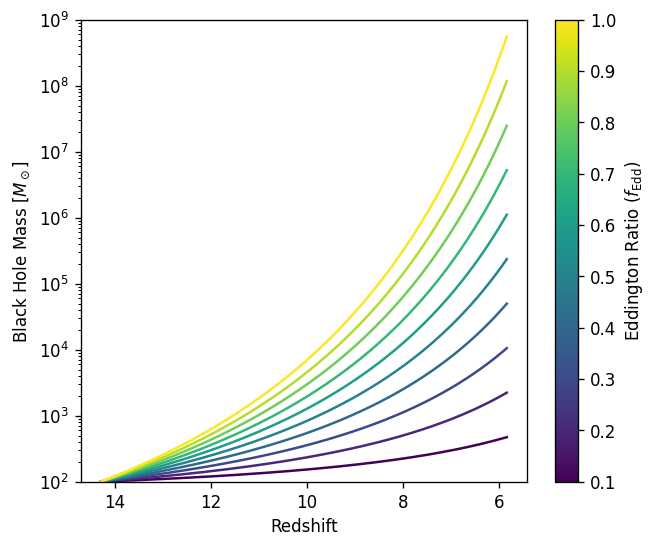

In [19]:
from matplotlib import cm
from matplotlib.colors import Normalize


def eddington_timescale(M_BH, eta):
    M_dot_Edd = eddington_accretion_rate(M_BH, eta)  # Eddington accretion rate
    t_Edd = M_BH / M_dot_Edd  # Eddington timescale in years
    return t_Edd  # in years


# Parameters
M0 = 1e2  # Initial black hole mass in solar masses
lambda_Edd_values = np.linspace(0.1, 1.0, 10)  # Range of Eddington ratios
eta = 0.1  # Radiative efficiency
t_end_gyr = 1  # Total time in Gyears

t_edd_myr = eddington_timescale(1e4, 0.1) / 1e6  # in Myr
# double_time =
print(t_edd_myr)

# Create color map and normalization for color bar
cmap = cm.viridis  # Choose a color map
norm = Normalize(
    vmin=lambda_Edd_values.min(), vmax=lambda_Edd_values.max()
)  # Normalize based on the range of lambda_Edd

# Plot
fig, ax = plt.subplots(figsize=(6, 5), dpi=120)

# Loop through different values of Eddington ratio
for lambda_Edd in lambda_Edd_values:
    times, masses = black_hole_growth_odeint(M0, lambda_Edd, eta, t_end_gyr)
    redshifts = z_from_t_myr(times / 1e6)
    color = cmap(norm(lambda_Edd))  # Get the corresponding color from the colormap
    ax.plot(redshifts, masses, label=f"$f_{{Edd}}$={lambda_Edd:.2f}", color=color)

# Add color bar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Empty array for colorbar
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label(r"Eddington Ratio ($f_{\rm Edd}$)")

# Set plot labels and limits
ax.set(
    xlabel="Redshift",
    ylabel="Black Hole Mass [$M_\\odot$]",
    yscale="log",
    ylim=[1e2, 1e9],
)

# Flip x-axis to show decreasing redshift
ax.invert_xaxis()

# Show plot
plt.show()

In [182]:
# now, we can make a grid of models that vary the starting mass,
# and given a certain eddington ratio accretion rate, what redshift does it reach a mass of 1e8 solar masses


def bh_eddington_model_grids(
    z_seed, massrange: tuple, eddington_range: tuple, z_obs=7, ngrid_points=50
):
    """
    Create a grid of black hole growth models for different initial masses and Eddington ratios.


    Parameters:
        z_seed (float): Redshift at which the black holes are seeded.
        massrange (array): Range of initial black hole masses in solar masses.
        eddington (array): Range of Eddington ratios.
        range (float): Maximum redshift to consider.
        ngrid_points (int): Number of grid points.

    Returns:
        array: 2D array of masses at redshift z_obs for each combination of initial mass and Eddington ratio.
    """
    radiative_efficiency = 0.1
    t_end = 13.8  # Total time in Gyears to evovel the black hole
    masses_array = np.zeros((ngrid_points, ngrid_points))
    t_myr_start = t_myr_from_z(z_seed)
    seed_masses = np.geomspace(*massrange, ngrid_points, endpoint=True)
    eddington = np.geomspace(*eddington_range, ngrid_points, endpoint=True)
    for i, m0 in enumerate(seed_masses):
        for j, lambda_Edd in enumerate(eddington):
            times, masses = black_hole_growth_odeint(
                m0,
                lambda_Edd,
                radiative_efficiency,
                t_end=t_end,
                t_myr_start=t_myr_start,
            )
            redshifts = z_from_t_myr(times / 1e6)
            idx = np.argmin(np.abs(z_obs - redshifts))
            masses_array[i, j] = masses[idx]
    return masses_array


# do Pop III seeds seeded at z =20 - 30, Barkana & Loeb 2001
pop3_mass_range = (10, 100)
clusterseed_mass_range = (1e3, 1e4)
ach_mass_range = (1e5, 1e6)
f_edd_range = (0.01, 10)
n = 100
pop3_masses = bh_eddington_model_grids(
    20, pop3_mass_range, f_edd_range, z_obs=6, ngrid_points=n 
)

# z = 10-20 Devecchi, B. ; Volonteri, M.  2009
clusterseed_mass = bh_eddington_model_grids(
    15, clusterseed_mass_range,f_edd_range, z_obs=6, ngrid_points=n 
)

# atomic cooling halos, seeded at z = 10 - 15, Cien, Bryan, Haiman 2010
ach_masses = bh_eddington_model_grids(
    10, ach_mass_range, f_edd_range, z_obs=6, ngrid_points=n 
)


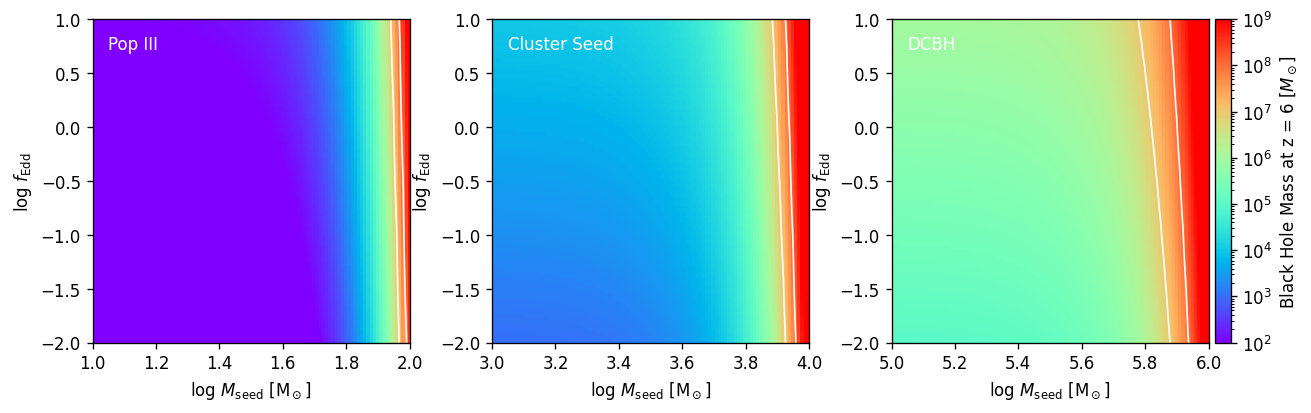

In [184]:
cmap = cm.rainbow  # Choose a color map

norm = LogNorm(vmin=100, vmax=1e9) # norm for the colorbar


# 3 panel plot
fig, ax = plt.subplots(1,3, figsize=(12, 3.5), dpi=120, )
plt.subplots_adjust(wspace=0.26)

plot_range = [pop3_mass_range, clusterseed_mass_range, ach_mass_range]

labels = ["Pop III", "Cluster Seed", "DCBH"]

for i, image in enumerate([pop3_masses, clusterseed_mass, ach_masses]):
    extent = [plot_range[i][0], plot_range[i][1], f_edd_range[0], f_edd_range[1]]
    extent_log = np.log10(extent)
    mass_im = ax[i].imshow(
        image, cmap=cmap, origin="lower", extent= extent_log , aspect="auto", norm=norm
    )
    ax[i].set(xlabel=r"log $M_{\rm seed} ~ [{\rm M_\odot}]$", ylabel=r"log $f_{\rm Edd}$")
    ax[i].text(0.05, 0.95, labels[i], ha='left', va='top', transform=ax[i].transAxes, color='white')
    
    # can do contours between 1e7 and 1e8 solar masses with labels
    ax[i].contour(image, levels=[1e7, 1e8], colors='w', extent=extent_log, linewidths=1)
    
# Add color bar
cbar_ax = ax[2].inset_axes([1.02, 0, 0.05, 1])
cbar = fig.colorbar(
    mass_im,
    cax=cbar_ax,
    
)  # flip the colorbar
cbar.set_label("Black Hole Mass at z = 6 [$M_\\odot$]")


plt.savefig("eddington_growth_models.png", dpi=300, bbox_inches="tight", pad_inches=0.1)